# 01. レスポンス生成 → 3ML プラグイン → 多天体同時フィット (目標 1, 2)

`Toy3MLplugin` は前方畳み込み(forward folding)解析の最小・完結ライブラリです。
このノートでは **レスポンスの生成を明示的に** 分けます:

    衛星軌道(pointing履歴) + 装置固有の応答 R0(theta,e)
        ── fold_response ──►  畳み込み済みレスポンス R[time, sky, e]  → ToyScanLike に入れる

装置固有なのはこの「レスポンス」だけで、Poisson 尤度・多天体の重ね合わせ・背景・3ML 連携は
基底 `ForwardFoldingLike` が面倒を見ます。

In [1]:
import logging; logging.disable(logging.INFO)
import numpy as np
import matplotlib.pyplot as plt
import astropy.io.fits as fits

from astromodels import Model
from threeML import DataList, JointLikelihood
from Toy3MLplugin import (load_sources, simulate_counts, BackgroundComponent,
                      make_scan_orbit, save_orbit_fits, load_orbit_fits,
                      intrinsic_response, fold_response)
from Toy3MLplugin.toy.scanner import ToyScanLike, toy_observation

E_EDGES = np.array([2.0, 10.0])   # エネルギー軸は用意しつつ、今は1ビンに潰す
FOV_SIGMA = 3.0                    # 漏れ込みで太る視野(コリメータのガウス幅)[deg]

18:48:04 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=12673830;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=12673831;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/astromodels/functions/functions_1D/functions.py#43\43]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=12673837;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=12673838;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/astromodels/functions/functions_1D/functions.py#65\65]8;;\
                  will not be available.                                                                           

18:48:05 WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=12673845;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=12673846;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

18:48:05 WARNING   WARNINGs here are NOT errors                                                      ]8;id=12673853;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=12673854;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py#45\45]8;;\

         WARNING   but are inform you about optional packages that can be installed                  ]8;id=12673860;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=12673861;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py#46\46]8;;\

...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=12673896;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=12673897;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py#126\126]8;;\
                  software installed and configured?                                                               

         WARNING   No fermitools installed                                              ]8;id=12673904;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=12673905;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=12673911;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=12673912;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=12673917;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=12673918;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=12673923;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=12673924;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

In [2]:
%matplotlib inline
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('retina')

### 1) 衛星軌道(pointing履歴)を作り、FITS に保存 → 読み戻す

軌道は簡略化(一定速度で銀経を掃く)。デモとして FITS のバイナリテーブルに保存します。

In [3]:
orbit = make_scan_orbit(scan_min=0, scan_max=30, n_t=500, dwell=200.0)
save_orbit_fits("orbit_toy.fits", **orbit)     # ← 軌道を FITS で保存
orbit = load_orbit_fits("orbit_toy.fits")      # ← 読み戻して使う
print("orbit keys:", list(orbit), " n_t =", orbit["l"].size)

orbit keys: ['time', 'l', 'b', 'exposure']  n_t = 500


In [ ]:
# for test
orbit_fits = fits.open('orbit_toy.fits')
orbit_fits[1].data

### 2) 装置固有の応答 R0(theta, e)  ── pointing にも軌道にもよらない

視線からの角距離 theta に対する「実効面積 × コリメータ透過」。単位つき(cm²)の astropy array。

> NOTE: いまは numpy / astropy(単位つき) の array。今後は FITS なり HDF5 で
> レスポンスを保存・配布する予定で、その差し替え口が `intrinsic_response` / `fold_response`。

R0: (300, 1) cm2


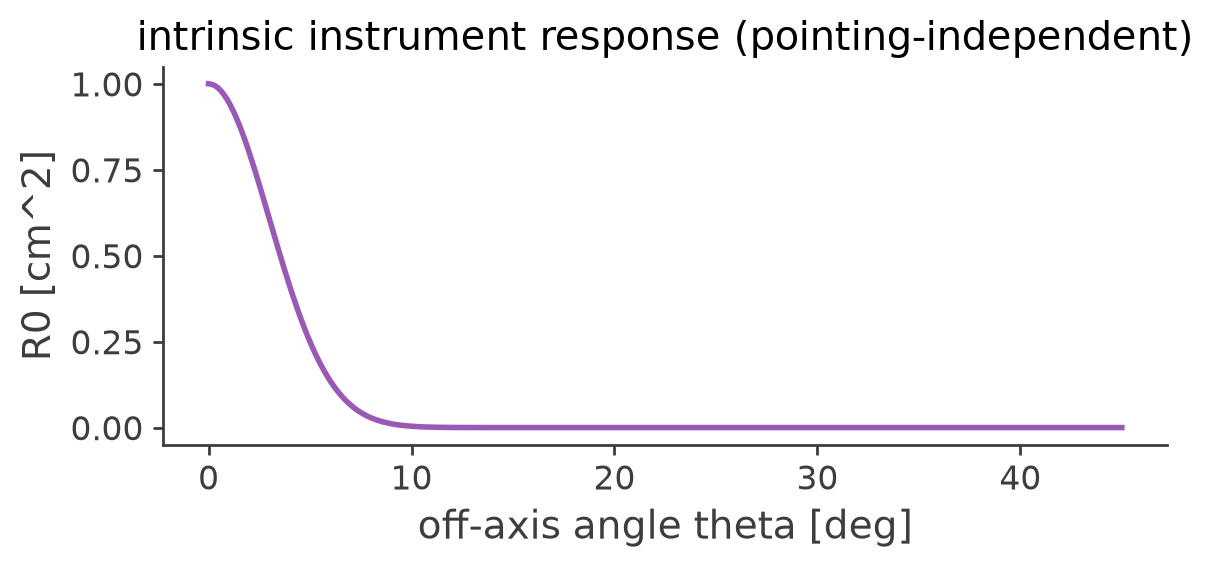

In [5]:
theta_grid = np.linspace(0, 45, 300)
R0, theta = intrinsic_response(theta_grid, E_EDGES, fov_sigma_deg=FOV_SIGMA)  # [n_theta, n_e] cm^2
print("R0:", R0.shape, R0.unit)

plt.figure(figsize=(6,3))
plt.plot(theta, R0[:,0].value)
plt.xlabel("off-axis angle theta [deg]"); plt.ylabel("R0 [cm^2]")
plt.title("intrinsic instrument response (pointing-independent)")
plt.tight_layout(); plt.show()

### 3) 軌道 × R0 を畳み込んで、前方作用素 R[time, sky, e] を作る

これがデータ空間(時間)とモデル空間(sky)を結ぶレスポンス。これを `ToyScanLike` に入れます。

folded response R: (500, 121, 1) cm2 s


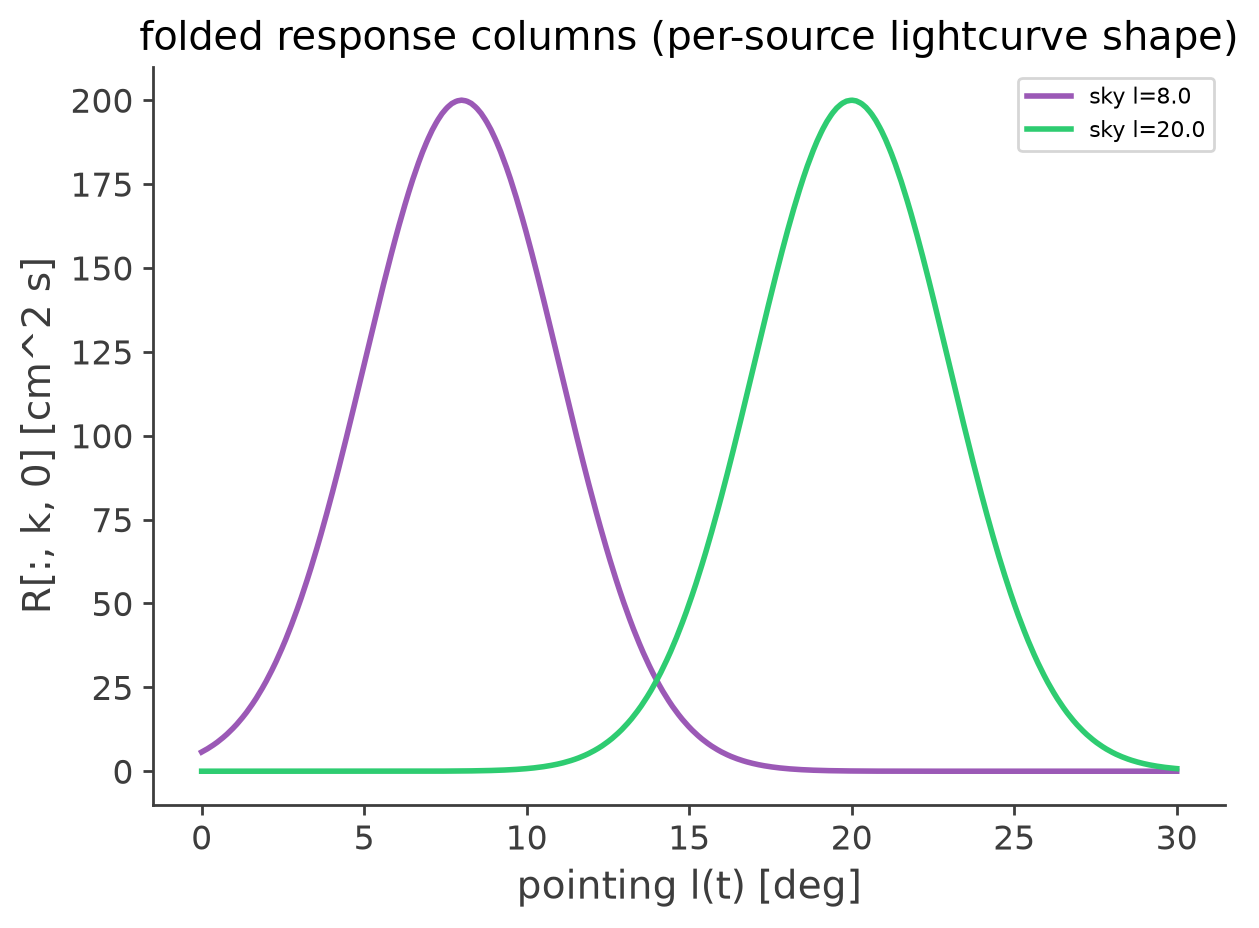

In [6]:
sky_l = np.arange(0, 30.01, 0.25)                     # モデル空間(銀経)グリッド
R = fold_response(orbit, R0, theta, sky_l)            # [n_t, n_sky, n_e]  cm^2 s
print("folded response R:", R.shape, R.unit)

# sky の2点(l=8, 20)に対応する列 = その位置の点源が作るライトカーブ形状
for l0 in (8.0, 20.0):
    k = int(np.argmin(np.abs(sky_l - l0)))
    plt.plot(orbit["l"], R[:,k,0].value, label=f"sky l={l0}")
plt.xlabel("pointing l(t) [deg]"); plt.ylabel("R[:, k, 0] [cm^2 s]")
plt.legend(); plt.title("folded response columns (per-source lightcurve shape)")
plt.tight_layout(); plt.show()

### 4) 真のモデルは YAML から組む(多天体リスト → astromodels.Model)

多天体同時フィットの枠組みは `astromodels.Model` がそのまま担います。
`load_sources` は Fermi の XML に相当する薄い YAML 層(`examples/sources.yaml`)。

In [7]:
truth, _ = load_sources("sources.yaml")   # SRC_A(l=8,K=1.0), SRC_B(l=20,K=0.5)
print(truth)

def perturbed_start():
    m, _ = load_sources("sources.yaml")
    m.SRC_A.spectrum.main.Powerlaw.K.value = 0.2
    m.SRC_B.spectrum.main.Powerlaw.K.value = 0.2
    return m

Model summary:

                  N
Point sources     2
Extended sources  0
Particle sources  0

Free parameters (2):
--------------------

                               value min_value max_value            unit
SRC_A.spectrum.main.Powerlaw.K   1.0       0.0    1000.0  keV-1 s-1 cm-2
SRC_B.spectrum.main.Powerlaw.K   0.5       0.0    1000.0  keV-1 s-1 cm-2

Fixed parameters (8):
(abridged. Use complete=True to see all fixed parameters)


Properties (0):
--------------------

(none)


Linked parameters (0):
----------------------

(none)

Independent variables:
----------------------

(none)

Linked functions (0):
----------------------

(none)



### 5) 観測ライトカーブを Poisson で合成

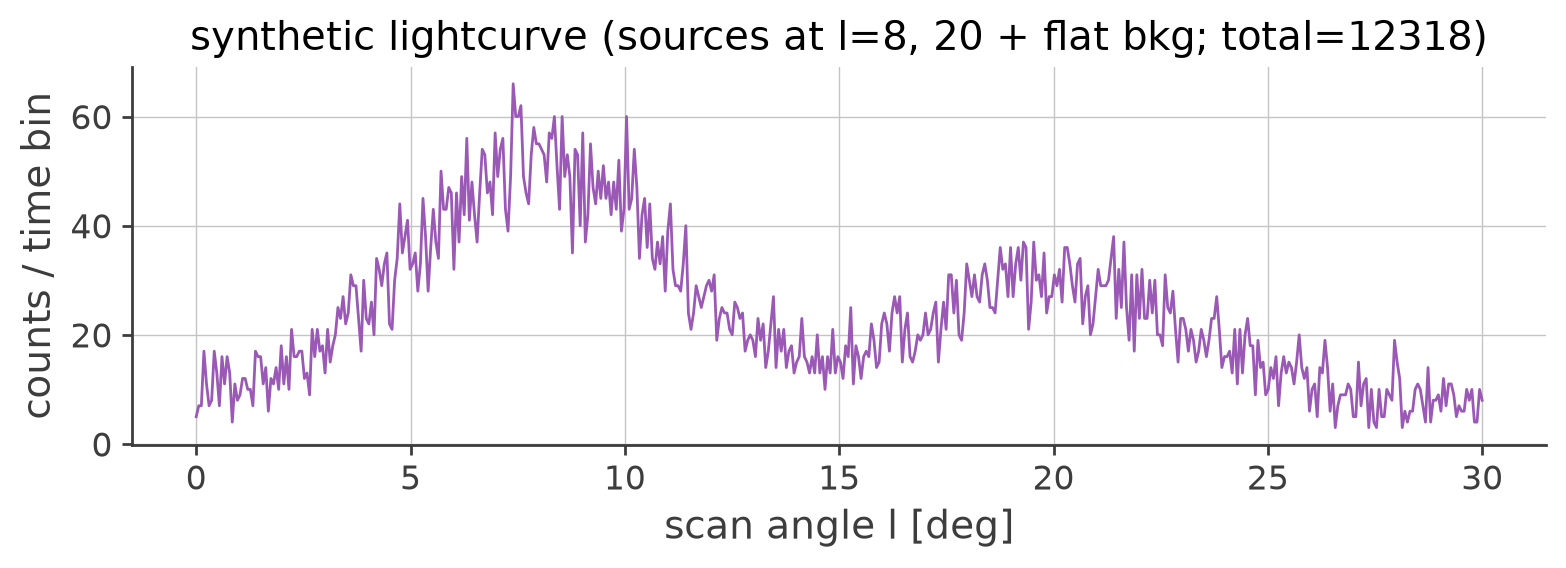

In [8]:
bkg = lambda: [BackgroundComponent("inst", np.ones(orbit["l"].size), value=8.0)]
sim = ToyScanLike("toy", toy_observation(np.zeros(orbit["l"].size), R, sky_l, orbit),
                  E_EDGES, backgrounds=bkg())
data = simulate_counts(sim, truth, np.random.default_rng(0))

plt.figure(figsize=(8,3))
plt.plot(orbit["l"], data, lw=1)
plt.xlabel("scan angle l [deg]"); plt.ylabel("counts / time bin")
plt.title(f"synthetic lightcurve (sources at l=8, 20 + flat bkg; total={int(data.sum())})")
plt.grid()
plt.tight_layout(); plt.show()

### 6) プラグインに観測を積んで 3ML で同時フィット

位置は固定、各源のフラックス K を自由にして `JointLikelihood` で最尤推定。背景 norm も一緒に。

Best fit values:

,result,unit
parameter,,
SRC_A.spectrum.main.Powerlaw.K,(9.99 -0.18 +0.19) x 10^-1,1 / (keV s cm2)
SRC_B.spectrum.main.Powerlaw.K,(5.20 -0.15 +0.16) x 10^-1,1 / (keV s cm2)
toy_bkg_inst_norm,7.79 +/- 0.28,


Correlation matrix:

1.00,0.33,-0.55
0.33,1.00,-0.63
-0.55,-0.63,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
toy,-28805.36422
total,-28805.36422


Values of statistical measures:

,statistical measures
AIC,-57604.680052
BIC,-57592.084615


K(SRC_A) = 0.999  (真 1.0)
K(SRC_B) = 0.520  (真 0.5)
toy_bkg_inst_norm = 7.792  (真 8.0)


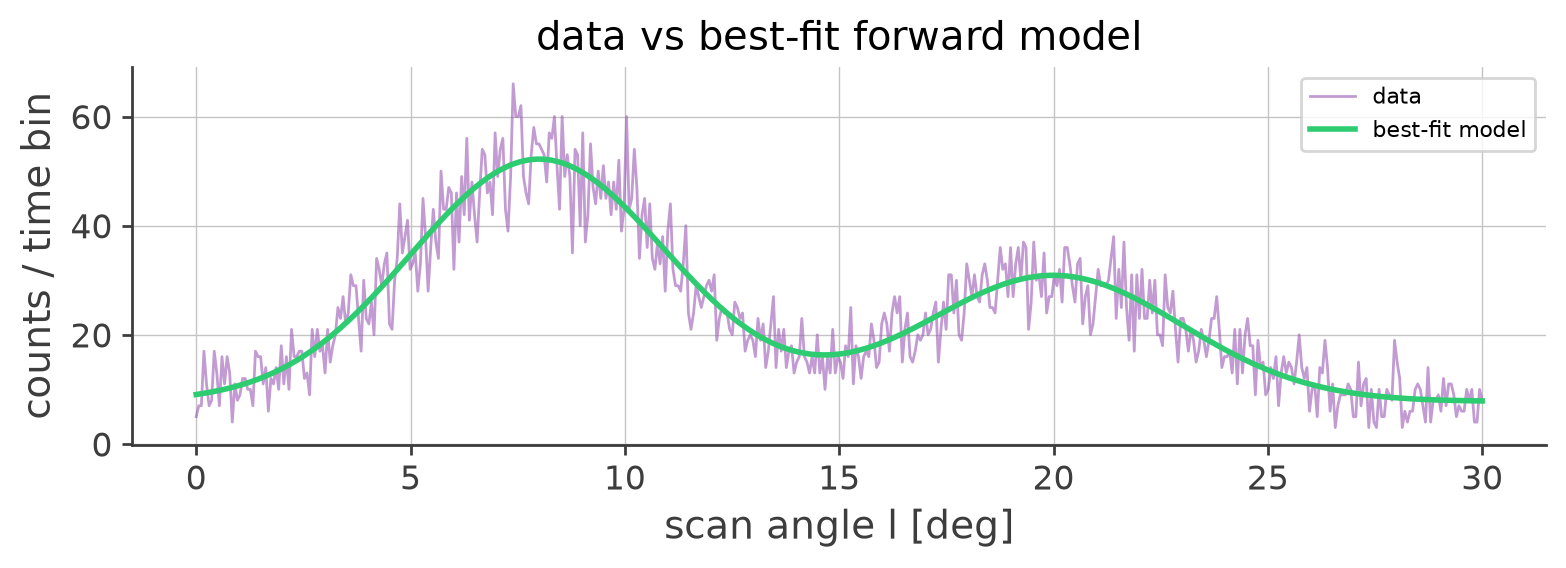

In [9]:
plugin = ToyScanLike("toy", toy_observation(data, R, sky_l, orbit), E_EDGES, backgrounds=bkg())
start = perturbed_start()
jl = JointLikelihood(start, DataList(plugin)); jl.set_minimizer("minuit")
_ = jl.fit()
print(f"K(SRC_A) = {start.SRC_A.spectrum.main.Powerlaw.K.value:.3f}  (真 1.0)")
print(f"K(SRC_B) = {start.SRC_B.spectrum.main.Powerlaw.K.value:.3f}  (真 0.5)")
for name, p in plugin.nuisance_parameters.items():
    print(f"{name} = {p.value:.3f}  (真 8.0)")

plugin.set_model(start); best = plugin.expected_counts()
plt.figure(figsize=(8,3))
plt.plot(orbit["l"], data, lw=1, alpha=0.6, label="data")
plt.plot(orbit["l"], best, lw=2, label="best-fit model")
plt.xlabel("scan angle l [deg]"); plt.ylabel("counts / time bin")
plt.grid()
plt.legend(); plt.title("data vs best-fit forward model"); plt.tight_layout(); plt.show()